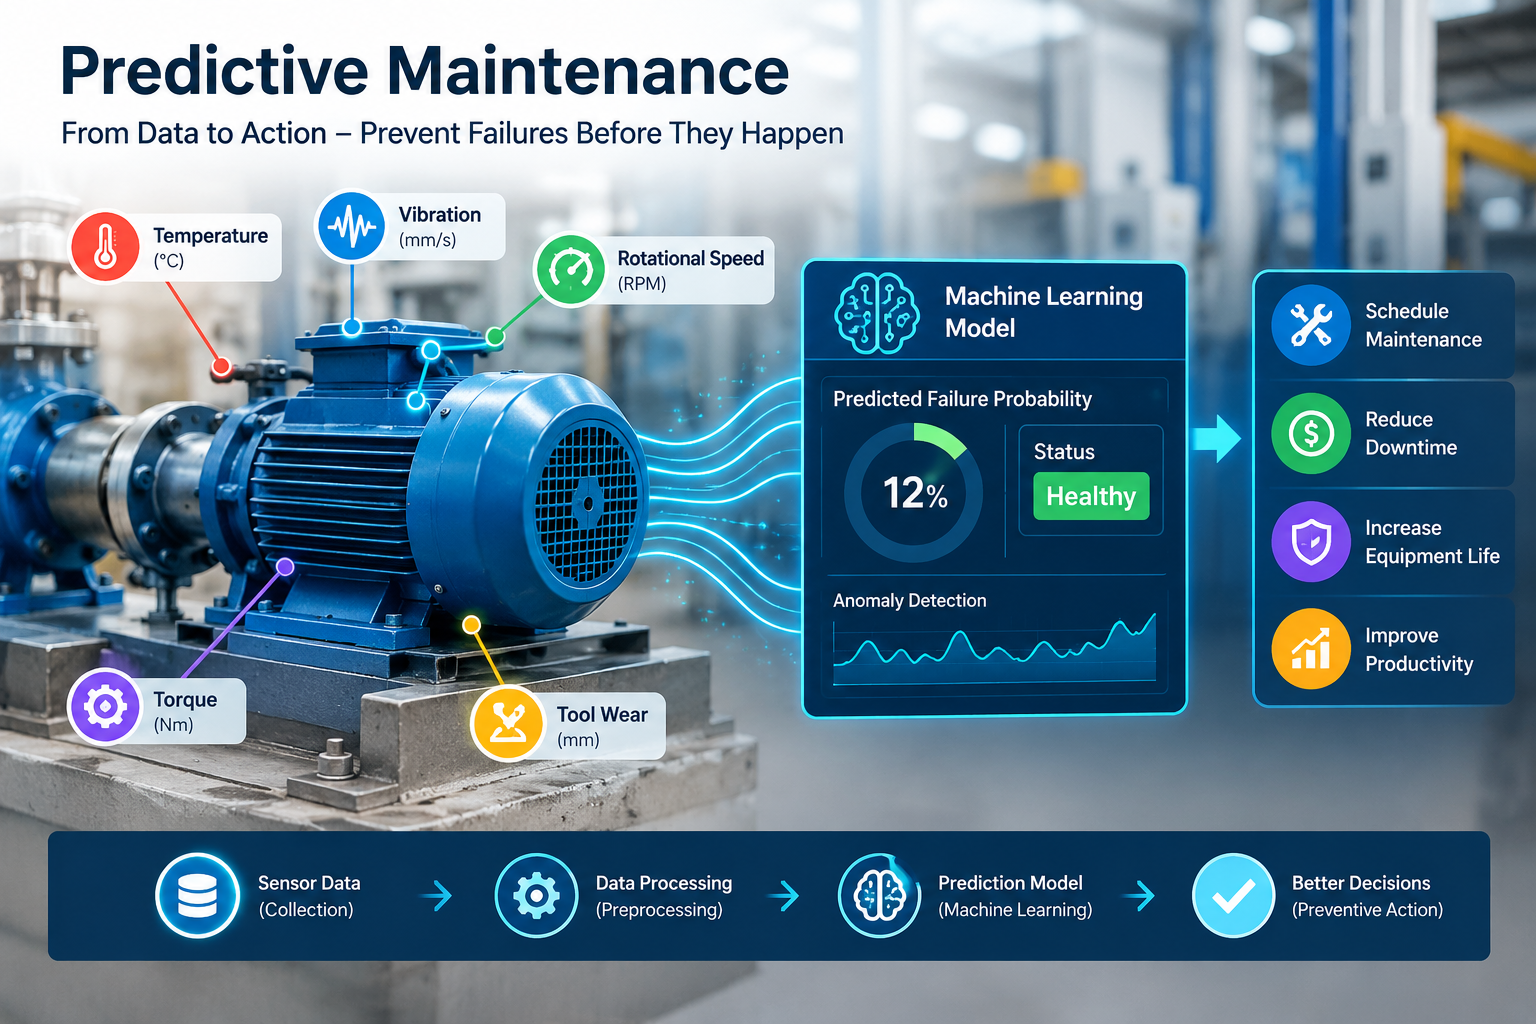

# Predictive Maintenance: Machine Failure Prediction

**Goal:** Predict whether an industrial machine is likely to fail from operating conditions and sensor measurements.

**Dataset:** AI4I-style predictive maintenance dataset.



## 1. Project Objective

Machine failures can stop production and increase maintenance cost. The goal is to build a classification model that estimates the probability of machine failure before an unexpected breakdown.

The project focuses on failure detection rather than predicting the exact time of failure.

## 2. Dataset Description

Important features include:
- `Type` – product/machine type category
- `Air temperature [K]` – surrounding air temperature
- `Process temperature [K]` – process temperature
- `Rotational speed [rpm]` – rotational speed
- `Torque [Nm]` – rotational load/force
- `Tool wear [min]` – accumulated tool usage/wear time
- `Target` – 0 = No Failure, 1 = Failure

`UDI`, `Product ID`, and `Failure Type` are not used as predictive inputs. `Failure Type` is removed because it describes the failure outcome and can cause target leakage.

## 3. Import Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:.3f}".format


###  4.Load Dataset

The AI4I 2020 Predictive Maintenance dataset is loaded using Pandas for further data analysis and model development.

In [52]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
DATA_PATH = "/content/drive/MyDrive/Gen_AI_Dataset/predictive_maintenance.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,No Failure
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,No Failure
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,No Failure
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,No Failure
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,No Failure


## 5. Basic Data Understanding

In [54]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())


Rows: 10000
Columns: 10

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']


In [55]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,No Failure
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,No Failure
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,No Failure
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,No Failure
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,No Failure
5,6,M14865,M,298.100,308.600,1425,41.900,11,0,No Failure
6,7,L47186,L,298.100,308.600,1558,42.400,14,0,No Failure
7,8,L47187,L,298.100,308.600,1527,40.200,16,0,No Failure
8,9,M14868,M,298.300,308.700,1667,28.600,18,0,No Failure
9,10,M14869,M,298.500,309.000,1741,28.000,21,0,No Failure


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [57]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000


## 6. Data Quality Check

In [58]:
#missing_value_counts
missing_counts = df.isnull().sum()
print("Missing values by column:")
print(missing_counts)


Missing values by column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64



### **Observation**: No missing values were found, so no missing-value imputation was required.

In [59]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Shape after removing duplicates:", df.shape)
else:
    print("No duplicate rows found.")

##  This checks for duplicate rows and if any exist, removes them and resets the DataFrame index.

Duplicate rows: 0
No duplicate rows found.


### **Observation**: No duplicate records were found in the dataset.

## 8.**Target Analysis and Class Imbalance**


### **Key Observation:** The failure class represents only a small percentage of the dataset, while normal-operation records dominate. This creates a **class imbalance problem**.

Because of this imbalance, accuracy alone may give a misleading impression of model performance. Therefore, failure-class Precision, Recall, F1-score, ROC-AUC, and PR-AUC will be considered during model evaluation.

In [60]:
print(df["Target"].value_counts())
print("\nPercentage:")
print(df["Target"].value_counts(normalize=True).mul(100).round(2))
#normalize=True → converts counts into proportions
# .mul(100) → converts proportions into percentages (.mul() means multiply   .,mnbv )
# .round(2) → rounds to 2 decimal places

Target
0    9661
1     339
Name: count, dtype: int64

Percentage:
Target
0   96.610
1    3.390
Name: proportion, dtype: float64


## 9. Categorical EDA: Type and Failure Rate

### ***Univariate analysis***

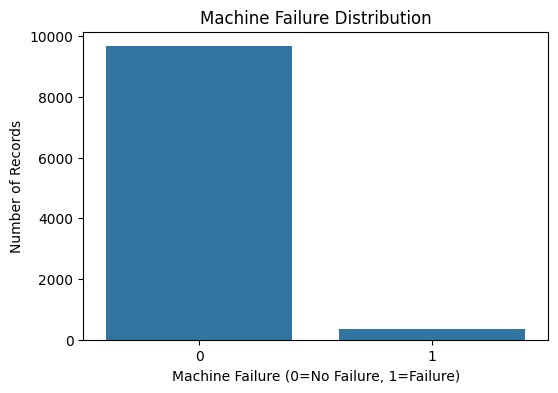

In [61]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Target")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0=No Failure, 1=Failure)")
plt.ylabel("Number of Records")
plt.show()

### Observation

The dataset is highly imbalanced, with substantially more normal-operation records than failure records.

This imbalance motivates the use of stratified splitting and imbalance-aware evaluation metrics.

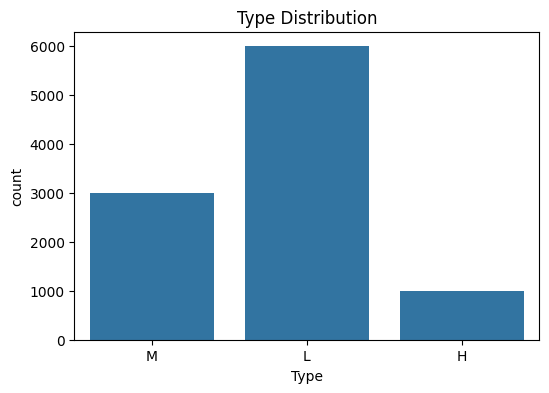

In [62]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Type")
plt.title("Type Distribution")
plt.show()

### Observation
L-type machines form the largest group in the dataset, while H-type machines are the smallest group.

## 10. Numerical EDA

### Identify Numerical Features

We separate numerical columns so that their distributions can be examined before modeling.

In [63]:
# Select only numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns
print(numerical_columns)

Index(['UDI', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target'],
      dtype='object')


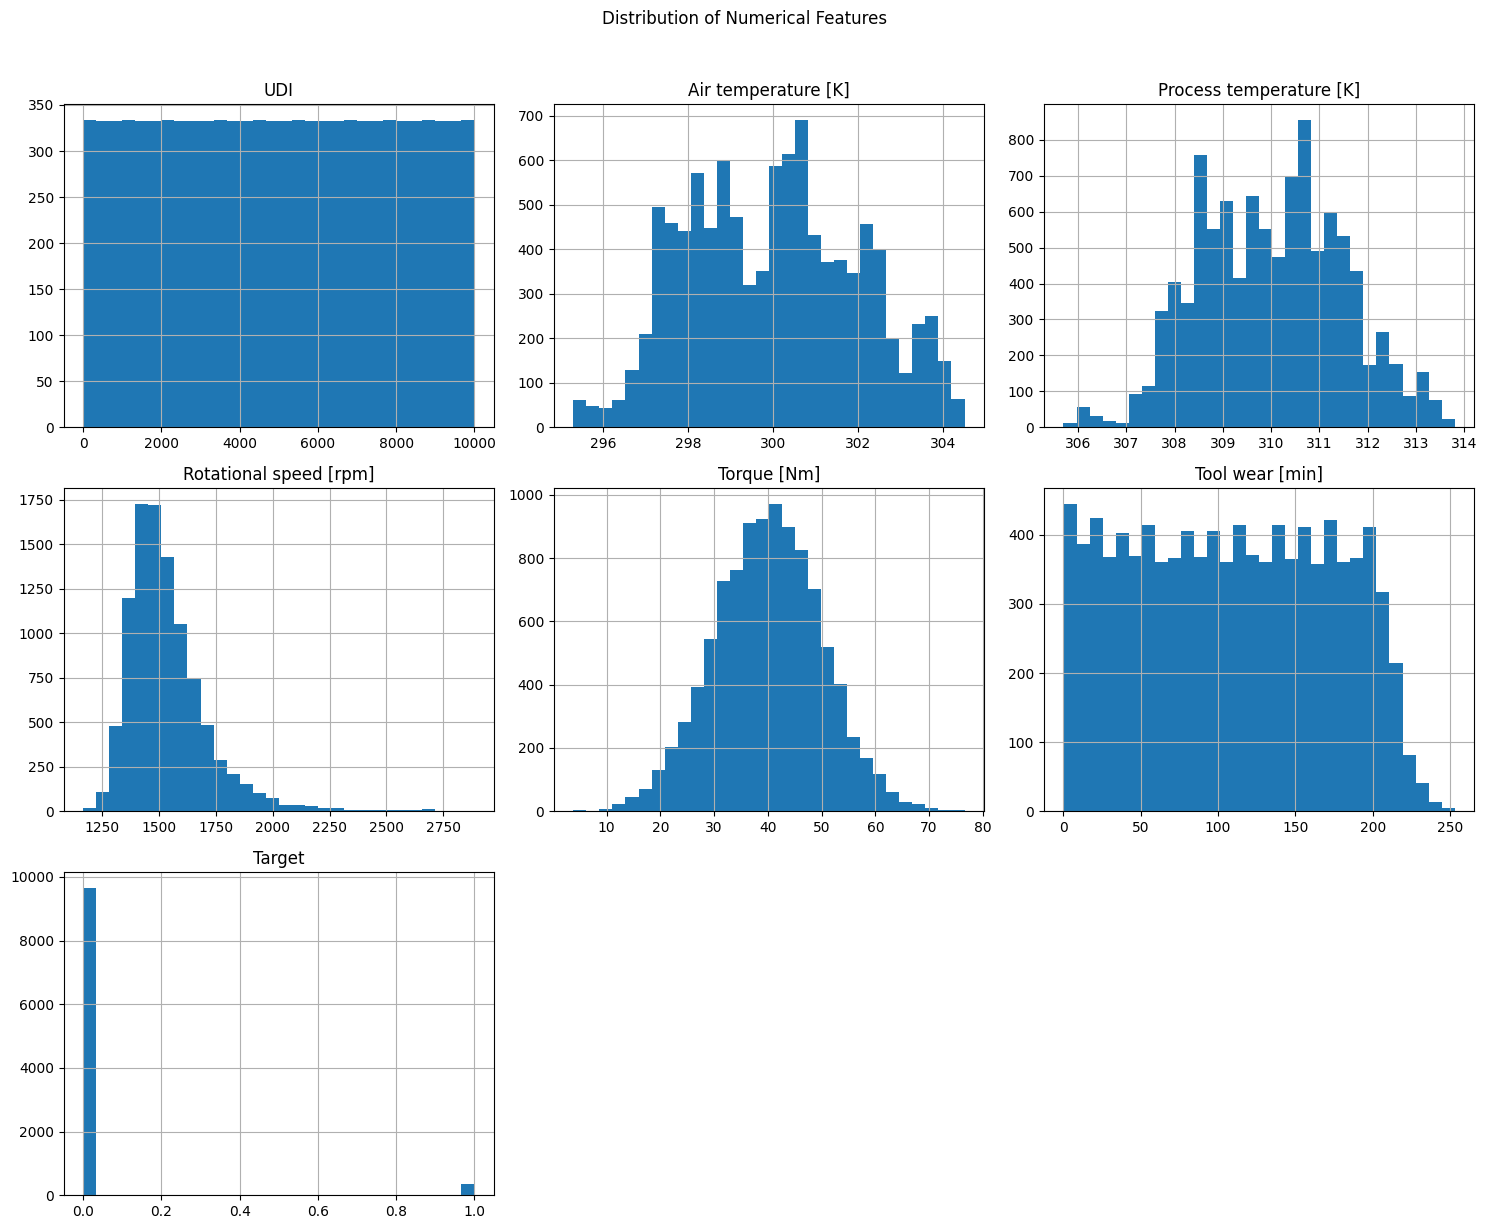

In [64]:
df[numerical_columns].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.tight_layout()#It automatically adjusts the spacing between the charts, labels, and titles so they don't overlap or get cut off.
plt.show()

### Observation

The numerical features have different distributions and ranges. Some features also show potential outliers, which should be considered when interpreting the data.

### ***Bivariate Analysis***

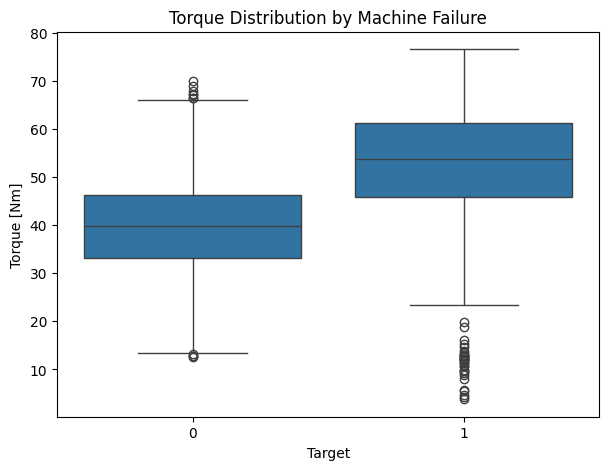

In [65]:
# Torque vs Machine Failure
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Target", y="Torque [Nm]")
plt.title("Torque Distribution by Machine Failure")
plt.show()

 **Observation:** Failure cases show a tendency toward higher torque values compared with normal-operation cases.

However, the distributions overlap, indicating that torque alone is not sufficient to predict failure.

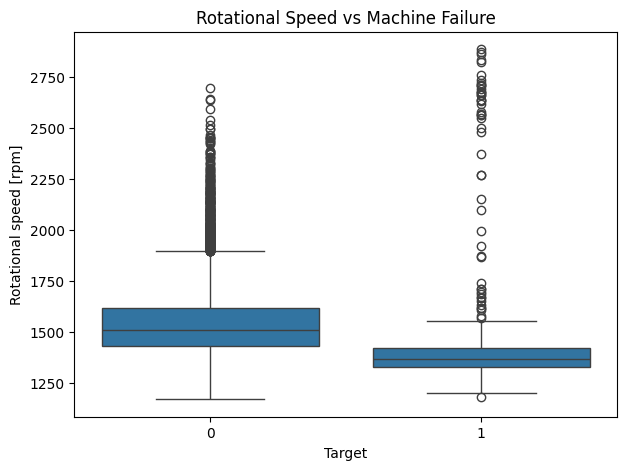

In [66]:
# Rotational Speed vs Machine Failure
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Target", y="Rotational speed [rpm]")
plt.title("Rotational Speed vs Machine Failure")
plt.show()

**Observation:** Failure cases tend to occur at lower rotational speeds in this dataset, although the distributions overlap and contain outliers.

Therefore, rotational speed alone cannot reliably determine machine failure.

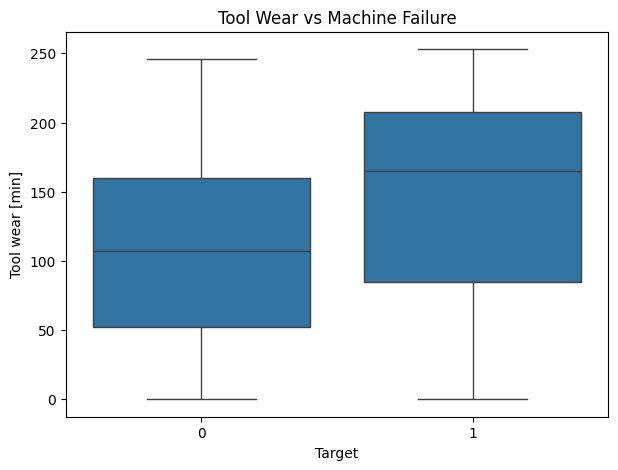

In [67]:
# Tool Wear vs Machine Failure
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Target", y="Tool wear [min]")
plt.title("Tool Wear vs Machine Failure")
plt.show()

**Observation:** Failure cases generally show higher tool-wear values than normal-operation cases.

This suggests that tool wear contains useful information for predicting machine failure, although it is not sufficient by itself.

Crosstab Code

### Failure Rate by Machine Type

A cross-tabulation is used to calculate the percentage of failures within each machine type.

Using `normalize="index"` converts the counts into row-wise percentages.

In [68]:
failure_by_type = pd.crosstab(
    df["Type"],
    df["Target"],
    normalize="index"
) * 100

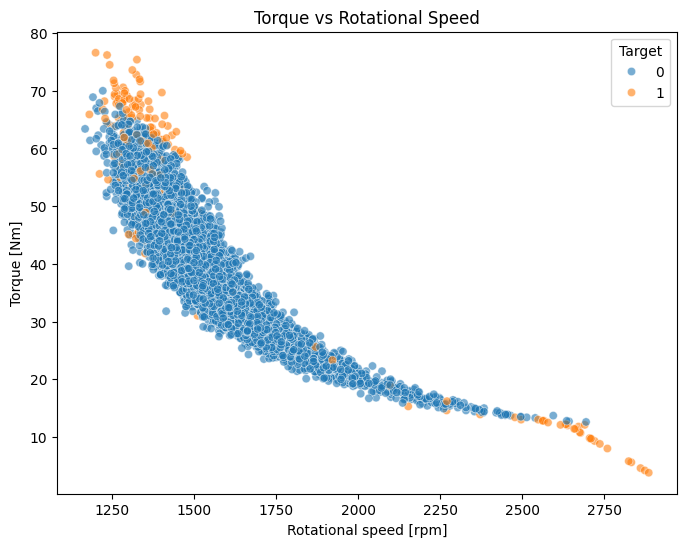

In [69]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Target",
    alpha=0.6
)
plt.title("Torque vs Rotational Speed")
plt.show()

**Observation**: Torque and rotational speed show a strong inverse relationship in the dataset.

Failure cases appear in particular regions of the feature space, suggesting that combinations of operating conditions may be more informative than individual features.

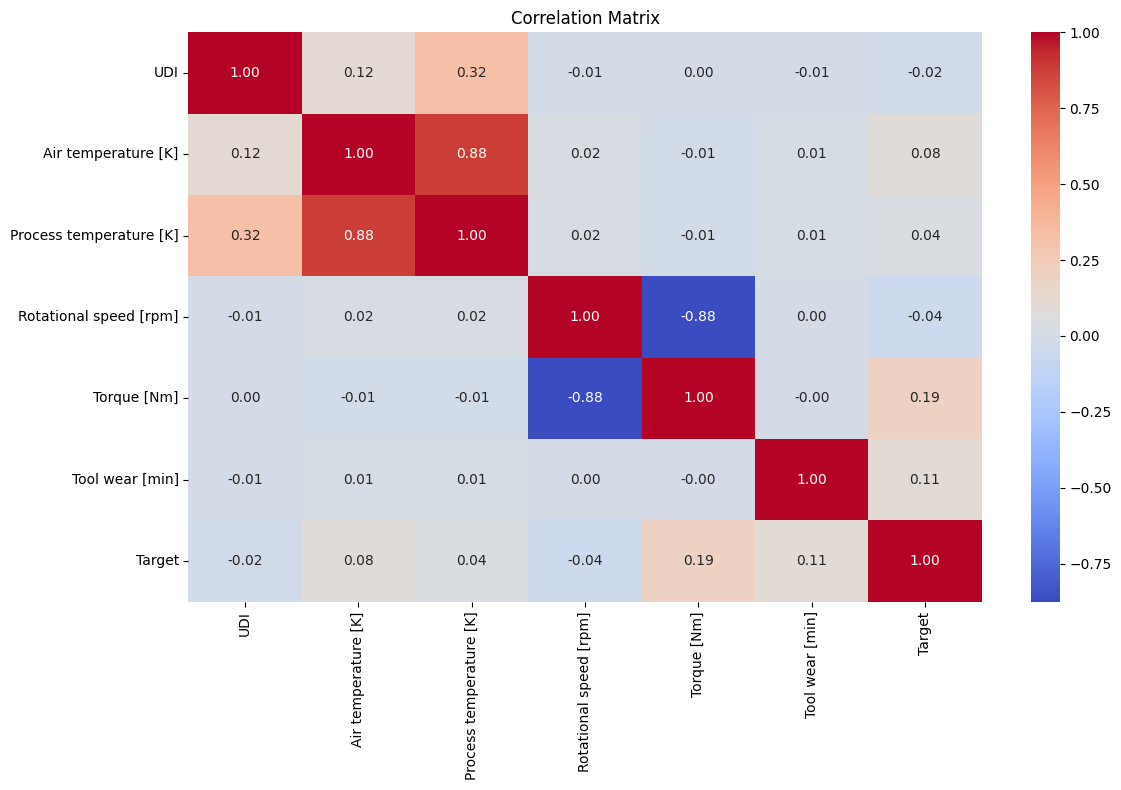

In [70]:
# Multivariate EDA
plt.figure(figsize=(12, 8))
correlation = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
# annot=True → show numbers inside the boxes.
# fmt=".2f"-This controls how many decimal places are displayed.
# cmap means color map.

**Observation:** Some features are strongly correlated with each other, such as air temperature and process temperature, and rotational speed and torque.

Correlation helps us understand relationships in the dataset, but correlation does not imply causation.

## 11. Leakage Audit and Feature Selection

`Failure Type` describes the type of failure after a failure occurs. Using it to predict `Target` would give the model information about the answer. Therefore it is removed. Identifiers such as `UDI` and `Product ID` are also removed because they are IDs rather than useful operating measurements.

### Feature Selection Decisions

| Feature | Decision | Reason |
|---|---|---|
| `UDI` | Remove | Identifier, not a useful machine operating feature |
| `Product ID` | Remove | Identifier rather than a machine condition |
| `Failure Type` | Remove | Contains information about the failure outcome |

In [71]:
drop_columns = ["UDI", "Product ID", "Failure Type"]

existing_drop_columns = []

for c in drop_columns:
    if c in df.columns:
        existing_drop_columns.append(c)

df_model = df.drop(columns=existing_drop_columns).copy()
# df_model  - contains the remaining data after removing:

print("Dropped columns:", existing_drop_columns)
print("Remaining columns:")
print(df_model.columns.tolist())

Dropped columns: ['UDI', 'Product ID', 'Failure Type']
Remaining columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']


### Observation

`Failure Type` was removed because it describes the type of failure and could leak information about the target.

Identifier columns were also removed because they do not represent meaningful machine operating conditions.

## 12. Feature Engineering



### Engineered Features

| Feature | Formula | Purpose |
|---|---|---|
| `Temperature_Difference` | Process Temperature − Air Temperature | Captures the temperature gap |
| `Power_Proxy` | Torque × Rotational Speed | Represents a load/power-related signal |
| `ToolWear_Torque` | Tool Wear × Torque | Captures interaction between wear and mechanical load |

In [72]:
df_model["Temperature_Difference"] = (
    df_model["Process temperature [K]"] - df_model["Air temperature [K]"])# k= Kelvin → temperature unit

df_model["Power_Proxy"] = (
    df_model["Torque [Nm]"] * df_model["Rotational speed [rpm]"])# rpm = Revolutions per minute → rotational speed
#min = Minute → time unit
df_model["ToolWear_Torque"] = (
    df_model["Tool wear [min]"] * df_model["Torque [Nm]"])#Nm = Newton-meter → torque unit

df_model[["Temperature_Difference", "Power_Proxy", "ToolWear_Torque"]].head()

,Temperature_Difference,Power_Proxy,ToolWear_Torque
0,10.500,66382.800,0.000
1,10.500,65190.400,138.900
2,10.400,74001.200,247.000
3,10.400,56603.500,276.500
4,10.500,56320.000,360.000


### Observation

The engineered features combine existing sensor measurements to represent relationships that may be useful for identifying machine failure.

These features are designed to give the model additional information beyond the raw measurements.

### Outlier Check

In [73]:
Q1 = df_model.select_dtypes(include=np.number).quantile(0.25)
Q3 = df_model.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((df_model.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR))|
                 (df_model.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).sum()
#   Between the limits → Normal value
print("Potential outlier count by numerical column:")
print(outlier_count.sort_values(ascending=False))

# We do not automatically delete these rows because extreme sensor values
# can be meaningful for failure prediction.

Potential outlier count by numerical column:
Rotational speed [rpm]     418
Target                     339
Torque [Nm]                 69
Power_Proxy                 60
ToolWear_Torque             20
Air temperature [K]          0
Process temperature [K]      0
Tool wear [min]              0
Temperature_Difference       0
dtype: int64


### Outlier Check

The Interquartile Range (IQR) method is used to identify potential outliers in numerical features.

Outliers are counted for inspection rather than automatically removed because extreme machine readings may represent genuine operating conditions.

## 13. Define Features (X) and Target (y)

In [74]:
X = df_model.drop("Target", axis=1)
y = df_model["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 9)
y shape: (10000,)


In [75]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature_Difference', 'Power_Proxy', 'ToolWear_Torque']


## 14. Train-Validation-Test Split

`stratify=y` keeps the failure proportion approximately similar in both training and test sets, which is important for an imbalanced classification problem.

### Why Three Splits?

The data is divided into:

- **Training set** → used to train the models
- **Validation set** → used for model comparison, regularization decisions, and threshold tuning
- **Final test set** → kept untouched until the final evaluation

In [76]:
# First split: Development data + untouched final test data

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

# Second split: Training data + validation data

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=42,
    stratify=y_dev)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Final test data:", X_test.shape)

print("\nFailure rates:")
print("Training:", round(y_train.mean() * 100, 2), "%")
print("Validation:", round(y_val.mean() * 100, 2), "%")
print("Final Test:", round(y_test.mean() * 100, 2), "%")

Training data: (6400, 9)
Validation data: (1600, 9)
Final test data: (2000, 9)

Failure rates:
Training: 3.39 %
Validation: 3.38 %
Final Test: 3.4 %


### Key Observation

Stratified splitting keeps the failure proportion approximately consistent across training, validation, and final test sets.

The final test set remains untouched during model selection and threshold tuning.

## Preprocessing Strategy



| Feature Type | Transformation |
|---|---|
| Numerical | StandardScaler |
| Categorical | OneHotEncoder |

In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

### Why use a Pipeline?

The preprocessing steps and model are kept together so that the same transformations are consistently applied during training and prediction.

## 16. Baseline Model 1 — Logistic Regression

In [78]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42))])

logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_val)

print("Logistic Regression - Validation Results")
print(
    classification_report(
        y_val,
        y_pred_lr,
        target_names=["Normal", "Failure"],
        zero_division=0))

Logistic Regression - Validation Results
              precision    recall  f1-score   support

      Normal       0.99      0.84      0.91      1546
     Failure       0.15      0.83      0.26        54

    accuracy                           0.84      1600
   macro avg       0.57      0.84      0.59      1600
weighted avg       0.96      0.84      0.89      1600



### **Observation**: Logistic Regression provides a useful baseline for comparison with the more complex tree-based models.

## 17. Baseline Model 2 — Decision Tree

In [79]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=8,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)
y_pred_dt = decision_tree_model.predict(X_val)

print("Decision Tree - Validation Results")
print(
    classification_report(
        y_val,
        y_pred_dt,
        target_names=["Normal", "Failure"],
        zero_division=0))

Decision Tree - Validation Results
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97      1546
     Failure       0.39      0.83      0.53        54

    accuracy                           0.95      1600
   macro avg       0.69      0.89      0.75      1600
weighted avg       0.97      0.95      0.96      1600



### **Observation:** The Decision Tree captures nonlinear patterns, but its validation performance is lower than the ensemble-based models.

## 18. Baseline Model 3 — Random Forest

In [80]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_val)

print("Random Forest - Validation Results")

print(
    classification_report(
        y_val,
        y_pred_rf,
        target_names=["Normal", "Failure"],
        zero_division=0
    )
)

Random Forest - Validation Results
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1546
     Failure       0.97      0.70      0.82        54

    accuracy                           0.99      1600
   macro avg       0.98      0.85      0.91      1600
weighted avg       0.99      0.99      0.99      1600



### **Observation:** Random Forest performs strongly and provides a useful ensemble baseline for comparison with Gradient Boosting.

## 19. Baseline Model 4 — Gradient Boosting

In [81]:
gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train the model using training data
gradient_model.fit(X_train, y_train)

# Evaluate on validation data
y_pred_gb = gradient_model.predict(X_val)

print("Gradient Boosting - Validation Results")
print(classification_report(
    y_val,
    y_pred_gb,
    target_names=["Normal", "Failure"],
    zero_division=0
))

Gradient Boosting - Validation Results
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1546
     Failure       0.98      0.78      0.87        54

    accuracy                           0.99      1600
   macro avg       0.98      0.89      0.93      1600
weighted avg       0.99      0.99      0.99      1600



### **Observation:** Gradient Boosting provides strong validation performance and becomes the baseline model selected for further investigation.

## 20. Compare All Baseline Models

In [82]:
def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_probability = model.predict_proba(X_val)[:, 1]

    return {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_probability),
        "PR-AUC": average_precision_score(y_val, y_probability)
    }


models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_model
}


results = {
    name: evaluate_model(model, X_val, y_val)
    for name, model in models.items()
}


results_df = pd.DataFrame(results).T

results_df.sort_values("F1 Score", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Gradient Boosting,0.992,0.977,0.778,0.866,0.987,0.895
Random Forest,0.989,0.974,0.704,0.817,0.963,0.851
Decision Tree,0.951,0.391,0.833,0.533,0.909,0.759
Logistic Regression,0.840,0.154,0.833,0.260,0.929,0.468


### **Model Comparison Observation**

The four baseline models show different performance levels across the evaluation metrics.

Gradient Boosting provides the strongest overall validation performance, particularly on F1 and PR-AUC, making it the candidate for further improvement.

Because the failure class is rare, F1 and PR-AUC are given more importance than accuracy alone.

## 21. Why Accuracy Alone Is Not Enough

If failures are rare, a model can get very high accuracy by predicting `No Failure` for most machines. For predictive maintenance, missing an actual failure can be more costly than sending an unnecessary inspection alert. Therefore, pay particular attention to **failure-class recall, precision, F1, ROC-AUC and PR-AUC**.


If 96.6% of machines are normal, a model that predicts every machine as normal could still achieve approximately 96.6% accuracy while detecting zero failures.

Therefore, failure Recall and F1-score are important for this problem.

## 22. Confusion Matrix — Baseline Best-F1 Model

Baseline best-F1 model: Gradient Boosting


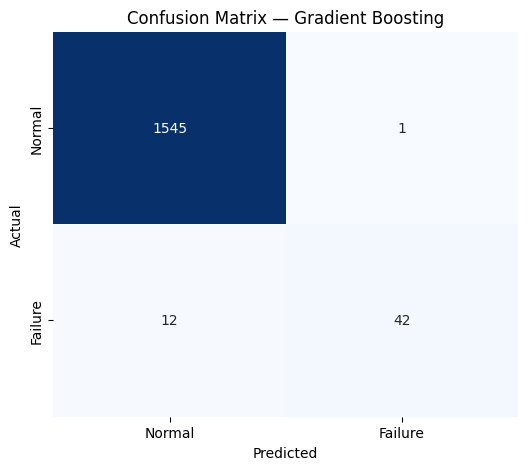

In [83]:
baseline_best_name = results_df["F1 Score"].idxmax()

baseline_best_model = models[baseline_best_name]

baseline_best_pred = baseline_best_model.predict(X_val)

print("Baseline best-F1 model:", baseline_best_name)

cm = confusion_matrix(y_val, baseline_best_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Failure"],
    yticklabels=["Normal", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {baseline_best_name}")

plt.show()

## 23. ROC Curve

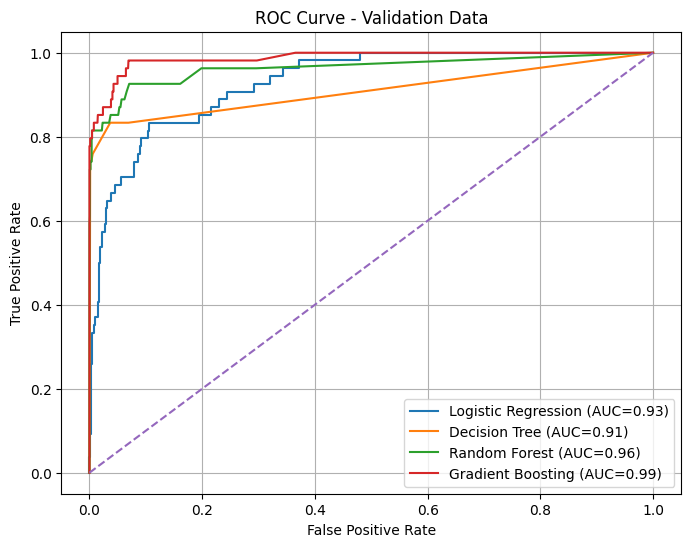

In [84]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    probability = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, probability)

    auc = roc_auc_score(y_val, probability)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Validation Data")

plt.legend()

plt.grid(True)

plt.show()

### Observation

Gradient Boosting achieves the highest ROC-AUC among the baseline models on the validation data, indicating strong overall separation between normal and failure cases.

ROC-AUC evaluates model discrimination across different probability thresholds.

## 24. Precision-Recall Curve

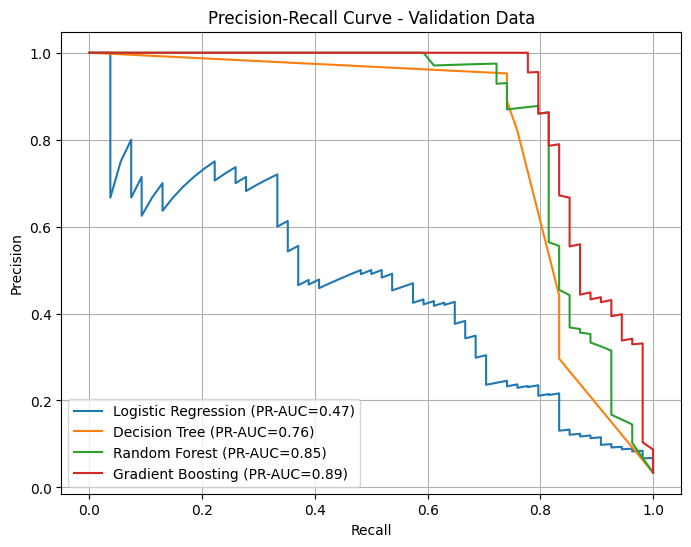

In [85]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    probability = model.predict_proba(X_val)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_val,
        probability
    )

    pr_auc = average_precision_score(
        y_val,
        probability
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={pr_auc:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Validation Data")

plt.legend()

plt.grid(True)

plt.show()

### Observation

Gradient Boosting achieves the highest PR-AUC among the baseline models.

Because machine failures are rare, the Precision-Recall curve is particularly useful for evaluating performance on the minority failure class.

##  Final Model — Regularized Gradient Boosting

The baseline Gradient Boosting model showed strong performance but had a larger training-validation gap.

Regularization is applied to reduce model complexity and improve generalization.

In [86]:
regularized_gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.03,
            max_depth=2,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

regularized_gb_model.fit(X_train, y_train)

print("Regularized Gradient Boosting model trained successfully!")

Regularized Gradient Boosting model trained successfully!


## Check Training vs Validation Performance

### Why Check Training vs Validation F1?

A model may perform very well on training data but poorly on unseen data if it has overfit.

Therefore, we compare training and validation F1-score.

A smaller gap generally indicates better generalization.

In [87]:
train_pred = regularized_gb_model.predict(X_train)
val_pred = regularized_gb_model.predict(X_val)

train_f1 = f1_score(y_train, train_pred, zero_division=0)
val_f1 = f1_score(y_val, val_pred, zero_division=0)

f1_gap = train_f1 - val_f1

print("Final Model: Regularized Gradient Boosting")
print("Training F1:", round(train_f1, 3))
print("Validation F1:", round(val_f1, 3))
print("F1 Gap:", round(f1_gap, 3))

Final Model: Regularized Gradient Boosting
Training F1: 0.904
Validation F1: 0.875
F1 Gap: 0.029


### Observation

The relatively small gap suggests that the final regularized model generalizes better than the original Gradient Boosting model.

##  Probability Threshold Tuning

The default classification threshold is usually 0.50.

However, for an imbalanced predictive-maintenance problem, a different threshold may provide a better balance between precision and recall.

Therefore, several thresholds are evaluated using the validation data.

In [88]:
regularized_gb_val_probabilities = (
    regularized_gb_model.predict_proba(X_val)[:, 1]
)

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

regularized_gb_threshold_results = []

for threshold in thresholds:

    predictions = (
        regularized_gb_val_probabilities >= threshold
    ).astype(int)

    regularized_gb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_val, predictions, zero_division=0
        )
    })

regularized_gb_threshold_df = pd.DataFrame(
    regularized_gb_threshold_results
)

regularized_gb_threshold_df

,Threshold,Precision,Recall,F1
0,0.200,0.878,0.796,0.835
1,0.250,0.878,0.796,0.835
2,0.300,0.915,0.796,0.851
3,0.350,0.956,0.796,0.869
4,0.400,1.000,0.796,0.887
5,0.450,1.000,0.796,0.887
6,0.500,1.000,0.778,0.875


In [89]:
best_threshold = 0.40

print("Selected threshold:", best_threshold)

print(
    regularized_gb_threshold_df[
        regularized_gb_threshold_df["Threshold"] == best_threshold
    ]
)

Selected threshold: 0.4
   Threshold  Precision  Recall    F1
4      0.400      1.000   0.796 0.887


### Selected Threshold

The validation results show that a threshold of **0.40** provides an F1-score of approximately **0.887**.

The threshold is selected using validation data and then kept fixed for the final test evaluation.

## 28. Final Evaluation on Untouched Test Data

The final test set has not been used for model selection or threshold tuning.

It is now used once to estimate how the final model performs on unseen data.

In [90]:
# Final prediction probabilities on untouched test data
test_probabilities = (
    regularized_gb_model.predict_proba(X_test)[:, 1]
)

# Apply the selected validation threshold
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

print("Final Model: Regularized Gradient Boosting")
print("Final Threshold:", best_threshold)

print("\nFinal Classification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Normal", "Failure"],
        zero_division=0
    )
)

Final Model: Regularized Gradient Boosting
Final Threshold: 0.4

Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
     Failure       1.00      0.81      0.89        68

    accuracy                           0.99      2000
   macro avg       1.00      0.90      0.95      2000
weighted avg       0.99      0.99      0.99      2000



In [91]:
final_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

final_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

print("Final ROC-AUC:", round(final_roc_auc, 3))
print("Final PR-AUC:", round(final_pr_auc, 3))

Final ROC-AUC: 0.966
Final PR-AUC: 0.895


##  Final Model Performance

| Metric | Result |
|---|---:|
| Model | Regularized Gradient Boosting |
| Threshold | 0.40 |
| Accuracy | 0.994 |
| Precision | 1.000 |
| Failure Recall | 0.809 |
| Failure F1 | 0.894 |
| ROC-AUC | 0.966 |
| PR-AUC | 0.895 |

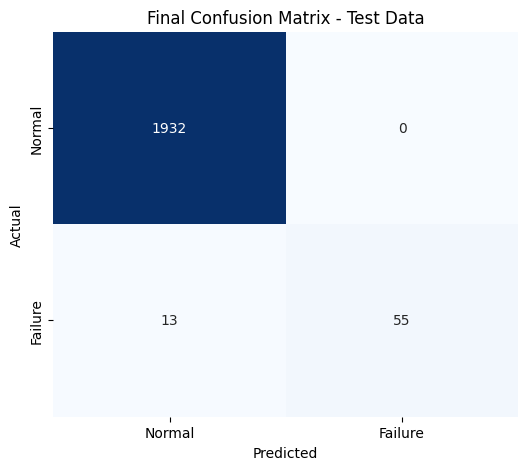

In [92]:
cm_final = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Failure"],
    yticklabels=["Normal", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix - Test Data")

plt.show()

### Confusion Matrix Interpretation

The final test confusion matrix contains:

- **1932** correctly identified normal machines
- **55** correctly detected failures
- **13** missed failures
- **0** false failure alerts

The model therefore detected 55 of the 68 actual failure cases in the test set.

## 30. Feature Importance

In [93]:
final_classifier = regularized_gb_model.named_steps["classifier"]

feature_names = (
    regularized_gb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,num__Power_Proxy,0.345
5,num__Temperature_Difference,0.283
7,num__ToolWear_Torque,0.275
2,num__Rotational speed [rpm],0.044
9,cat__Type_L,0.035
4,num__Tool wear [min],0.015
3,num__Torque [Nm],0.002
1,num__Process temperature [K],0.001
0,num__Air temperature [K],0.000
8,cat__Type_H,0.000


### Why Feature Importance?

Feature importance shows which input features the Gradient Boosting model relied on most when making predictions.

It helps us understand the model beyond its performance metrics.

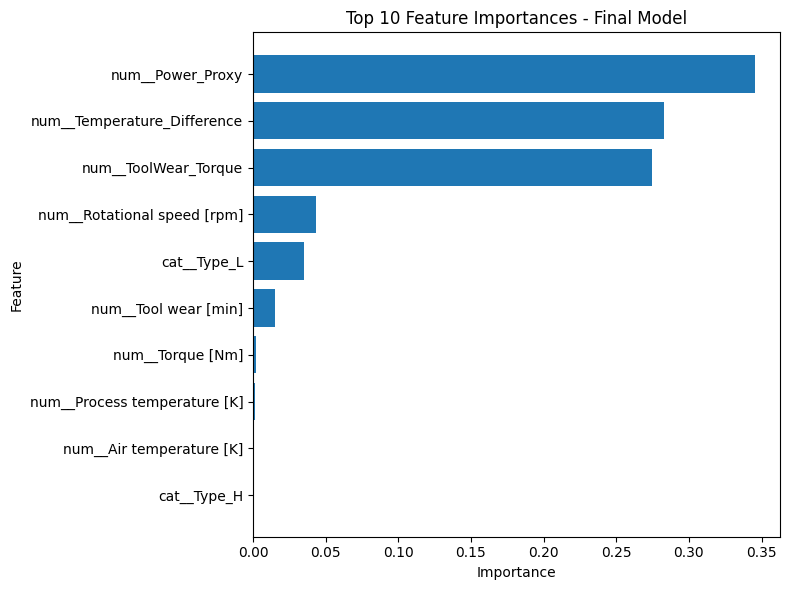

In [94]:
top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Final Model")

plt.tight_layout()
plt.show()

### Observation

The engineered features `Power_Proxy`, `Temperature_Difference`, and `ToolWear_Torque` contribute heavily to the model's predictions.

This suggests that combinations of machine operating conditions provide important information for failure-risk prediction.

Feature importance indicates model reliance; it does not prove that a feature directly causes failure.

# New Machine Failure Risk Prediction

### Objective

After evaluating the model, we test it on a new machine record to demonstrate how the trained system can produce a failure-risk prediction for previously unseen input values.

In [95]:
# New machine sensor values

new_data = pd.DataFrame({
    "Type": ["L"],
    "Air temperature [K]": [310],
    "Process temperature [K]": [320],
    "Rotational speed [rpm]": [1200],
    "Torque [Nm]": [65],
    "Tool wear [min]": [200]
})

# Create the same engineered features used during training

new_data["Temperature_Difference"] = (
    new_data["Process temperature [K]"]
    - new_data["Air temperature [K]"]
)

new_data["Power_Proxy"] = (
    new_data["Rotational speed [rpm]"]
    * new_data["Torque [Nm]"]
)

new_data["ToolWear_Torque"] = (
    new_data["Tool wear [min]"]
    * new_data["Torque [Nm]"]
)

# Predict failure probability
failure_probability = (
    regularized_gb_model.predict_proba(new_data)[:, 1][0]
)

# Apply the selected threshold
prediction = int(
    failure_probability >= best_threshold
)

print("Failure Probability:",
      round(failure_probability * 100, 2), "%")

if prediction == 1:
    print("Prediction: Machine Failure Risk")
else:
    print("Prediction: Normal Operation")

Failure Probability: 81.51 %
Prediction: Machine Failure Risk


### Prediction Interpretation

**Failure Probability:** 81.51%

**Decision Threshold:** 40%

Because:

`81.51% ≥ 40%`

the model predicts:

**Machine Failure Risk**

## 32. Save the Final Model and Threshold

In [96]:
import joblib

joblib.dump(
    regularized_gb_model,
    "predictive_maintenance_model.pkl"
)

joblib.dump(
    best_threshold,
    "failure_threshold.pkl"
)

print("Final model saved successfully.")
print("Final threshold saved successfully.")

Final model saved successfully.
Final threshold saved successfully.


### Why Save the Model?

Saving the trained model allows it to be reused later without retraining it from scratch.

The classification threshold is also saved because it is part of the final prediction logic.

## 33. Verify the Saved Model

In [97]:
loaded_model = joblib.load(
    "predictive_maintenance_model.pkl"
)

loaded_threshold = joblib.load(
    "failure_threshold.pkl"
)

loaded_probability = (
    loaded_model.predict_proba(new_data)[:, 1][0]
)

loaded_prediction = int(
    loaded_probability >= loaded_threshold
)

print("Loaded Model Failure Probability:",
      round(loaded_probability * 100, 2), "%")

if loaded_prediction == 1:
    print("Loaded Model Prediction: Machine Failure Risk")
else:
    print("Loaded Model Prediction: Normal Operation")

Loaded Model Failure Probability: 81.51 %
Loaded Model Prediction: Machine Failure Risk


### Observation

The loaded model produces the same failure probability of **81.51%** and the same **Machine Failure Risk** prediction.

This confirms that the saved model and threshold were loaded successfully.

## 34. Limitations

- The model is trained on the AI4I 2020 benchmark dataset.
- The model may not directly generalize to every real-world manufacturing environment.
- Feature importance does not establish causal relationships.
- The model predicts failure risk but does not identify the exact physical cause of failure.
- The system should support maintenance decisions rather than replace engineering inspection.

## 35. Future Improvements

- Connect the model to real-time machine sensor data.
- Build a Flask API for real-time prediction.
- Create an interactive web dashboard.
- Store prediction history for maintenance monitoring.
- Monitor model performance after deployment.
- Retrain the model periodically with new production data.

## 36. Conclusion

This project developed a machine-failure risk prediction system using the AI4I predictive-maintenance dataset.

The workflow included data quality analysis, class-imbalance handling, leakage removal, feature engineering, model comparison, regularization, probability-threshold tuning, and final evaluation on an untouched test set.

The final Regularized Gradient Boosting model achieved:

- **F1-score:** 0.894
- **Failure Recall:** 0.809
- **ROC-AUC:** 0.966
- **PR-AUC:** 0.895

The trained model was also saved, reloaded, and successfully verified on a new machine prediction.